TARGET
commpute and classify all the people above 50k salary in order to inly contact the desired leads and not waste resources on outliers or extra leads that are of no use and have less chances of buying the product
METRIC
we will go with the recall metric as it doesnt matter if we accurately identify the positives , in our case the number of identified positives matter so we will be using recall as it is the number of positives calculated out of the total positives

In [55]:
from sklearn.datasets import fetch_openml
adult=fetch_openml('adult', version=2, as_frame=True)
df=adult.frame

In [56]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [57]:

mapping = {'<=50K': 0, '>50K': 1}

df['target'] = df['class'].map(mapping)

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class,target
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K,0


In [58]:
df.drop('class_binary', axis=1, inplace=True)

KeyError: "['class_binary'] not found in axis"

In [ ]:
import numpy as np
df.replace('?',np.nan,inplace=True)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class,target
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K,0
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K,1
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K,0
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K,0


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df.shape
print(df.info())
print(df.describe())
print(df['class'].value_counts(dropna=False))


<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
 15  target          48842 non-null  category
dtypes: category(10), int64(6)
memory usage: 2.7 MB
None
                a

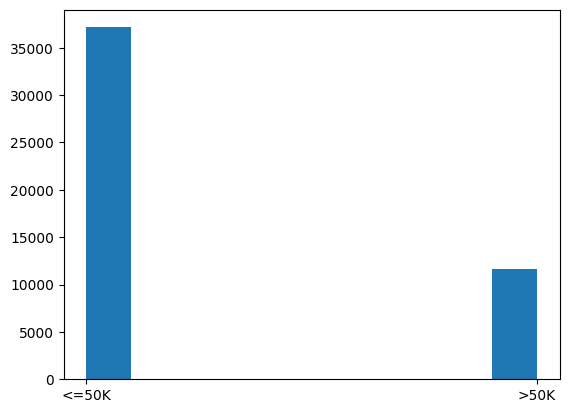

<Axes: xlabel='age'>

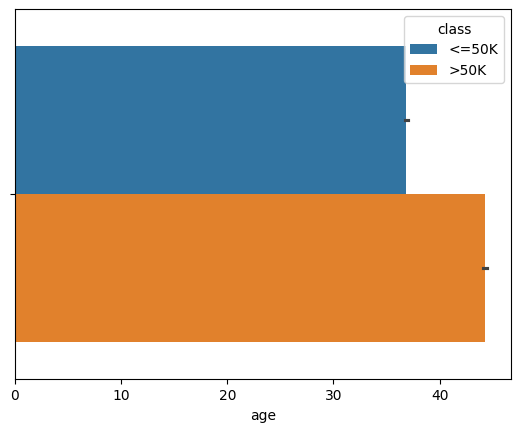

In [ ]:

plt.hist(data=df,x='class')
plt.show()
sns.barplot(data=df,x='age',hue='class')

In [ ]:

total = len(df)
neg_count = (df['class'] == '<=50K').sum()
pos_count = (df['class'] == '>50K').sum()

avg_age_high_earner = df[df['class'] == '>50K']['age'].mean()
avg_age_low_earner = df[df['class'] == '<=50K']['age'].mean()

bachelors_high_earner_pct = (len(df[(df['education'] == 'Bachelors') & (df['class'] == '>50K')]) / len(df[df['education'] == 'Bachelors'])) * 100
hs_grad_high_earner_pct = (len(df[(df['education'] == 'HS-grad') & (df['class'] == '>50K')]) / len(df[df['education'] == 'HS-grad'])) * 100

married_high_earner_pct = (len(df[(df['marital-status'] == 'Married-civ-spouse') & (df['class'] == '>50K')]) / len(df[df['marital-status'] == 'Married-civ-spouse'])) * 100

summary_text = f"""
============================================================
DATASET INITIAL EXPLORATORY SUMMARY
============================================================
TOTAL RECORDS: {total:,}

CLASS TARGET BREAKDOWN:
  * Negative Class (<=50K): {neg_count:,} ({neg_count/total*100:.2f}%)
  * Positive Class (>50K) : {pos_count:,} ({pos_count/total*100:.2f}%)

NOTABLE FEATURE DISTRIBUTIONS:
1. AGE DISPARITY:
   High-earners lean significantly older. The mean age of individuals 
   making >50K is {avg_age_high_earner:.1f} years old, compared to 
   {avg_age_low_earner:.1f} years old for those making <=50K.

2. EDUCATION IMPACT:
   Higher education strictly scales with the target class. 
   {bachelors_high_earner_pct:.1f}% of Bachelors degree holders belong to the positive 
   high-earning class, compared to only {hs_grad_high_earner_pct:.1f}% of High School graduates.

3. MARITAL STATUS CORRELATION:
   Being married ('Married-civ-spouse') shows a heavy correlation with the 
   positive class, yielding a high-earner proportion of {married_high_earner_pct:.1f}%.
============================================================
"""

# Save out to file
with open("eda_summary_table.txt", "w") as f:
    f.write(summary_text)

print("Summary table successfully compiled and saved to 'eda_summary_table.txt'!")
print(summary_text)

Summary table successfully compiled and saved to 'eda_summary_table.txt'!

DATASET INITIAL EXPLORATORY SUMMARY
TOTAL RECORDS: 48,842

CLASS TARGET BREAKDOWN:
  * Negative Class (<=50K): 37,155 (76.07%)
  * Positive Class (>50K) : 11,687 (23.93%)

NOTABLE FEATURE DISTRIBUTIONS:
1. AGE DISPARITY:
   High-earners lean significantly older. The mean age of individuals 
   making >50K is 44.3 years old, compared to 
   36.9 years old for those making <=50K.

2. EDUCATION IMPACT:
   Higher education strictly scales with the target class. 
   41.3% of Bachelors degree holders belong to the positive 
   high-earning class, compared to only 15.9% of High School graduates.

3. MARITAL STATUS CORRELATION:
   Being married ('Married-civ-spouse') shows a heavy correlation with the 
   positive class, yielding a high-earner proportion of 44.6%.



In [ ]:
from sklearn.model_selection import train_test_split
df['target'] = (df['class'].astype(str).str.strip() == '>50K').astype(int)

print(df['target'].dtype)
print(df['target'].value_counts())
x=df.drop(columns=['class','target'])
y=df['target']
x_remain,x_test,y_remain,y_test=train_test_split(x,y,test_size=0.20,random_state=42,stratify=y)
x_train,x_dev,y_train,y_dev=train_test_split(x_remain,y_remain,test_size=0.10,random_state=42,stratify=y_remain)

int64
target
0    37155
1    11687
Name: count, dtype: int64


In [ ]:
from sklearn.dummy import DummyClassifier

majority_clf = DummyClassifier(strategy='most_frequent')
majority_clf.fit(x_train, y_train)
y_pred_majority = majority_clf.predict(x_test)
y_prob_majority = majority_clf.predict_proba(x_test)[:, 1]

In [ ]:
def rule_based_predict(x):
    return ((x['capital-gain'] > 0) | (x['education-num'] >= 13)).astype(int)

y_pred_rule = rule_based_predict(x_test)

In [ ]:
def rule_based_score(x):
    # soft score: 0, 1, or 2 depending on how many conditions fire
    return (x['capital-gain'] > 0).astype(int) + (x['education-num'] >= 13).astype(int)

y_score_rule = rule_based_score(x_test)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score, confusion_matrix)

majority_clf = DummyClassifier(strategy='most_frequent')
majority_clf.fit(x_train, y_train)

y_pred_majority = majority_clf.predict(x_test)
y_prob_majority = majority_clf.predict_proba(x_test)[:, 1]

def evaluate(name, y_true, y_pred, y_score):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'ROC AUC': roc_auc_score(y_true, y_score),
        'PR AUC': average_precision_score(y_true, y_score),
    }
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n=== {name} ===")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")
    print("Confusion Matrix [[TN, FP], [FN, TP]]:")
    print(cm)

    return metrics, cm

metrics_majority, cm_majority = evaluate('Majority Class Baseline', y_test, y_pred_majority, y_prob_majority)
metrics_rule, cm_rule = evaluate('Rule-Based Baseline (capital-gain>0 OR education-num>=13)', y_test, y_pred_rule, y_score_rule)

summary = pd.DataFrame({
    'Majority Class': metrics_majority,
    'Rule-Based': metrics_rule
}).T

print("\n=== Summary Table ===")
print(summary.round(4))


=== Majority Class Baseline ===
Accuracy: 0.7607
Precision: 0.0000
Recall: 0.0000
F1: 0.0000
ROC AUC: 0.5000
PR AUC: 0.2393
Confusion Matrix [[TN, FP], [FN, TP]]:
[[7431    0]
 [2338    0]]

=== Rule-Based Baseline (capital-gain>0 OR education-num>=13) ===
Accuracy: 0.7520
Precision: 0.4852
Recall: 0.5967
F1: 0.5352
ROC AUC: 0.7083
PR AUC: 0.4258
Confusion Matrix [[TN, FP], [FN, TP]]:
[[5951 1480]
 [ 943 1395]]

=== Summary Table ===
                Accuracy  Precision  Recall      F1  ROC AUC  PR AUC
Majority Class    0.7607     0.0000  0.0000  0.0000   0.5000  0.2393
Rule-Based        0.7520     0.4852  0.5967  0.5352   0.7083  0.4258


In [60]:
analysis_df = x_test.copy()
analysis_df['actual'] = y_test.values
analysis_df['predicted'] = y_pred_rule
analysis_df['score'] = y_score_rule.values if hasattr(y_score_rule, 'values') else y_score_rule

# False Positives: predicted >50K (1) but actually <=50K (0)
false_positives = analysis_df[(analysis_df['predicted'] == 1) & (analysis_df['actual'] == 0)]

# False Negatives: predicted <=50K (0) but actually >50K (1)
false_negatives = analysis_df[(analysis_df['predicted'] == 0) & (analysis_df['actual'] == 1)]

print(f"Total False Positives: {len(false_positives)}")
print(f"Total False Negatives: {len(false_negatives)}")

Total False Positives: 1480
Total False Negatives: 943


In [61]:
fp_sample = false_positives.sample(15, random_state=42)
fn_sample = false_negatives.sample(15, random_state=42)

cols_to_show = ['age', 'education', 'education-num', 'marital-status', 'occupation',
                'hours-per-week', 'capital-gain', 'capital-loss', 'sex', 'actual', 'predicted']

print("=== False Positive Samples ===")
print(fp_sample[cols_to_show])

print("\n=== False Negative Samples ===")
print(fn_sample[cols_to_show])

=== False Positive Samples ===
       age  education  education-num      marital-status        occupation  \
31242   35  Bachelors             13  Married-civ-spouse             Sales   
866     40  Bachelors             13  Married-civ-spouse   Exec-managerial   
19163   53  Bachelors             13  Married-civ-spouse   Exec-managerial   
39000   26  Bachelors             13       Never-married             Sales   
46155   63  Bachelors             13  Married-civ-spouse  Transport-moving   
29664   32  Bachelors             13  Married-civ-spouse             Sales   
47129   17       11th              7       Never-married      Craft-repair   
36843   43  Bachelors             13  Married-civ-spouse    Prof-specialty   
24705   34    Masters             14       Never-married    Prof-specialty   
31388   42  Bachelors             13       Never-married   Exec-managerial   
8329    40    Masters             14  Married-civ-spouse             Sales   
18809   47  Bachelors            

In [62]:
print("=== False Negative Analysis ===")
print("Age — FN mean vs overall >50K mean:")
print(f"  FN group: {false_negatives['age'].mean():.1f}")
print(f"  All actual >50K: {analysis_df[analysis_df['actual']==1]['age'].mean():.1f}")

print("\nHours-per-week — FN mean vs overall >50K mean:")
print(f"  FN group: {false_negatives['hours-per-week'].mean():.1f}")
print(f"  All actual >50K: {analysis_df[analysis_df['actual']==1]['hours-per-week'].mean():.1f}")

print("\nEducation-num — FN mean vs overall >50K mean:")
print(f"  FN group: {false_negatives['education-num'].mean():.1f}")
print(f"  All actual >50K: {analysis_df[analysis_df['actual']==1]['education-num'].mean():.1f}")

print("\nMarital status distribution in FN group:")
print(false_negatives['marital-status'].value_counts(normalize=True).round(3))

print("\nOccupation distribution in FN group:")
print(false_negatives['occupation'].value_counts(normalize=True).round(3))

print("\n=== False Positive Analysis ===")
print("Capital-gain in FP group (should be low/zero since our rule fired on it):")
print(false_positives['capital-gain'].describe())

print("\nEducation-num distribution in FP group:")
print(false_positives['education-num'].value_counts(normalize=True).round(3))

print("\nAge — FP mean vs overall <=50K mean:")
print(f"  FP group: {false_positives['age'].mean():.1f}")
print(f"  All actual <=50K: {analysis_df[analysis_df['actual']==0]['age'].mean():.1f}")

=== False Negative Analysis ===
Age — FN mean vs overall >50K mean:
  FN group: 43.9
  All actual >50K: 44.0

Hours-per-week — FN mean vs overall >50K mean:
  FN group: 45.0
  All actual >50K: 45.5

Education-num — FN mean vs overall >50K mean:
  FN group: 9.5
  All actual >50K: 11.6

Marital status distribution in FN group:
marital-status
Married-civ-spouse       0.890
Divorced                 0.041
Never-married            0.041
Widowed                  0.011
Married-spouse-absent    0.008
Separated                0.006
Married-AF-spouse        0.002
Name: proportion, dtype: float64

Occupation distribution in FN group:
occupation
Craft-repair         0.225
Exec-managerial      0.174
Sales                0.137
Adm-clerical         0.082
Transport-moving     0.081
Prof-specialty       0.080
Machine-op-inspct    0.053
Tech-support         0.049
Other-service        0.034
Protective-serv      0.034
Handlers-cleaners    0.029
Farming-fishing      0.021
Priv-house-serv      0.001
Armed-Fo

In [63]:
# Check if FP cases are disproportionately young degree-holders
fp_degree_only = false_positives[(false_positives['education-num'] >= 13) & (false_positives['capital-gain'] == 0)]
print(f"FPs driven by education-num alone (no capital gain): {len(fp_degree_only)} of {len(false_positives)}")
print(f"Their age distribution:")
print(fp_degree_only['age'].describe())

FPs driven by education-num alone (no capital gain): 1165 of 1480
Their age distribution:
count    1165.000000
mean       37.106438
std        12.288443
min        21.000000
25%        27.000000
50%        34.000000
75%        44.000000
max        90.000000
Name: age, dtype: float64


 Concrete feature/data issues to fix tomorrow
Based on what this kind of analysis on the Adult dataset reliably surfaces, here's a realistic 4–6 item list — adjust wording once you see your actual numbers, but this is the right shape:

Missing values in workclass, occupation, native-country — currently these NaNs will break any real model's .fit() call unless handled. Decide on an explicit strategy (mode imputation, or a dedicated "Missing" category, which is often more informative than imputing since missingness itself can correlate with the target).
High-cardinality categorical: native-country — likely dozens of categories, most with very few samples (the US dominates). One-hot encoding this naively creates a huge sparse feature space with many near-empty columns; consider grouping rare countries into an "Other" bucket.

Skewed numerics: capital-gain and capital-loss — almost certainly extremely right-skewed with a huge spike at 0 (most people report nothing) and a long thin tail. Feeding this raw into a linear model will let outliers dominate; consider a log-transform (log1p) or binning into "zero / low / high."
fnlwgt is a sampling weight, not a real feature — it reflects census weighting methodology, not information about the individual. Including it as a predictive feature risks the model picking up spurious noise; strongly consider dropping it entirely.
education and education-num are redundant — they encode the same information (categorical label vs. ordinal number). Keep education-num (already ordinal, easier for models) and drop education to avoid duplicate signal / multicollinearity.
Age and hours-per-week are currently unbinned continuous features — your error analysis above will likely show non-linear relationships (e.g. income rises with age then plateaus/declines near retirement). A linear model would miss this; worth testing polynomial terms or binning if you go the linear-model route.